Super-resolution experience


Your detector sees an image after being subjected to a PSF. In matrix notation
𝑦 = 𝐴𝑥 + 𝑛
• A: linear operator (PSF blurring in this case)
• x: “True” image
• y: measured image
• n: noise (random uncorrelated for each pixel).

Experiment 1: Gaussian smoothing is invertible in Fourier
If A is “convolve with a gaussian” you can “convolve with the inverse of the gaussian”.
In python do the following:

1 Create or load a noiseless test image (eg: scikit image in “data” contains coffee, coins.
Or generate a 512x512 matrix with some rectangles and/or circles)
2 Smooth with a gaussian kernel (scipy.ndimage.gaussian_filter.) with a relatively small
sigma (0.5 pixels – 3 pixels…).
3Do the inverse of the convolution. How to do it? (btw, try also in Fourier)

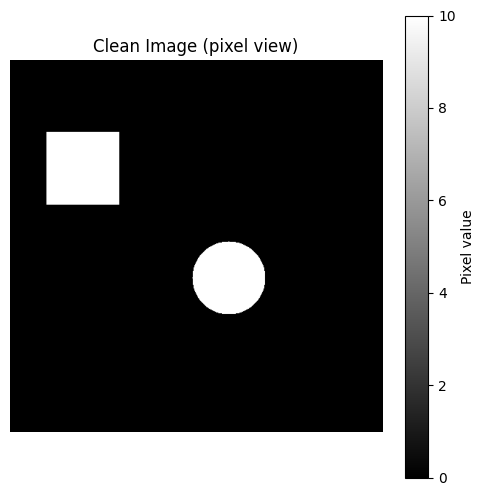

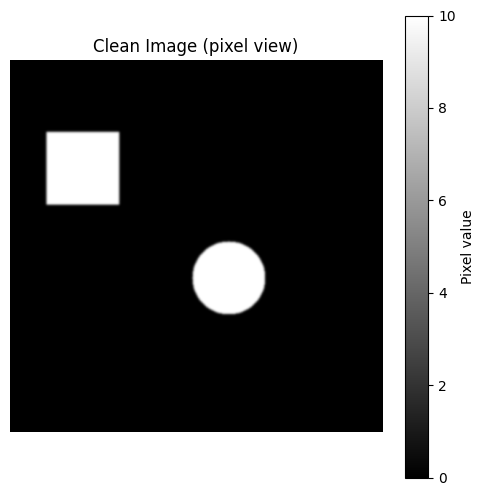

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

clean_image = np.zeros((512, 512))
unitary_matrix = np.zeros((100, 100))
unitary_matrix[:] = 10

for i in range(100, 200):
    for j in range(50, 150):
        clean_image[i, j] += unitary_matrix[i-100, j-50]
        
        
cx, cy = 300, 300   # centro del cerchio (spostato a destra)
r = 50              # raggio
value = 10

for i in range(cx - r, cx + r):
    for j in range(cy - r, cy + r):
        if (i - cx)**2 + (j - cy)**2 <= r**2:
            clean_image[i, j] += value


plt.figure(figsize=(6, 6))
plt.imshow(clean_image, cmap='gray')
plt.colorbar(label='Pixel value')
plt.title("Clean Image (pixel view)")
plt.axis('off')
plt.show()

clean_image = gaussian_filter(clean_image, sigma=1.5)


plt.figure(figsize=(6, 6))
plt.imshow(clean_image, cmap='gray')
plt.colorbar(label='Pixel value')
plt.title("Clean Image (pixel view)")
plt.axis('off')
plt.show()


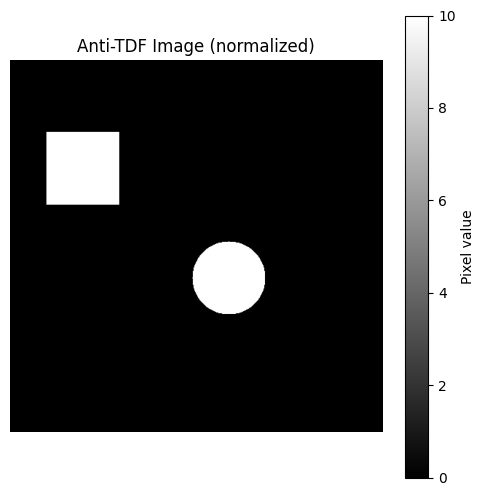

In [73]:
from scipy.fft import fftn, ifftn,fftshift
import numpy as np

import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def gaussian_kernel2d(shape,sigma):
    H, W = shape
    yy, xx = np.ogrid[:H, :W]
    
    cy,cx = H // 2, W // 2 #guassiana al centro del del quadrato
    g = np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sigma**2))
    
    g /= g.sum()
    
    return g



# Immagine pulita con cerchio e quadrato
clean_image = np.zeros((512, 512))
unitary_matrix = np.ones((100, 100)) * 10

clean_image[100:200, 50:150] += unitary_matrix

cx, cy, r, value = 300, 300, 50, 10
for i in range(cx - r, cx + r):
    for j in range(cy - r, cy + r):
        if (i - cx)**2 + (j - cy)**2 <= r**2:
            clean_image[i, j] += value

# Applicazione filtro Gaussiano
blurred_image = gaussian_filter(clean_image, sigma=1.5)

# FFT
tdf_image_b = fftn(blurred_image)


# Anti-convoluzione stabile con epsilon
epsilon = 1e-5
tdf_gaussian = fftn(fftshift(gaussian_kernel2d(clean_image.shape, sigma=1.5))) #fftshift per ricentrare la gaussiana ed eliminare coefficienti di fase

tdf_image = tdf_image_b / (tdf_gaussian + epsilon) #per evitare artefatti o valori fuori scala
antitdf = np.real(ifftn(tdf_image))
antitdf_display = antitdf - antitdf.min()
antitdf_display = antitdf_display / antitdf_display.max() * 10






# Visualizzazione
plt.figure(figsize=(6, 6))
plt.imshow(antitdf, cmap='gray', vmin=0, vmax=10)

plt.colorbar(label='Pixel value')
plt.title("Anti-TDF Image (normalized)")
plt.axis('off')
plt.show()


Add noise. Random normal noise. Start with a small amount. To simulate the physics
of the acquisition, when do you add it?
What happens to the deconvolved images when noise is present?




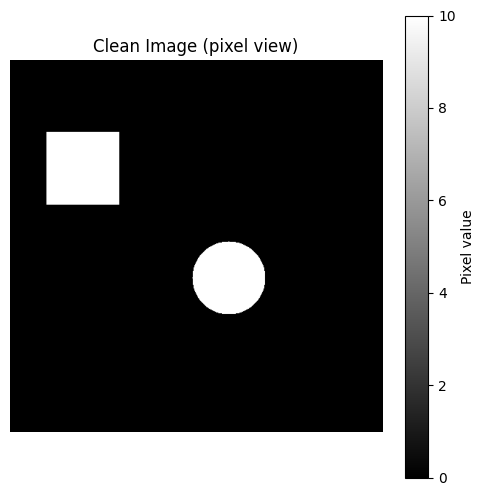

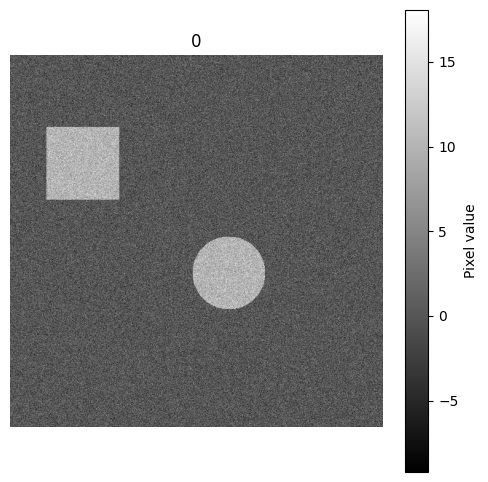

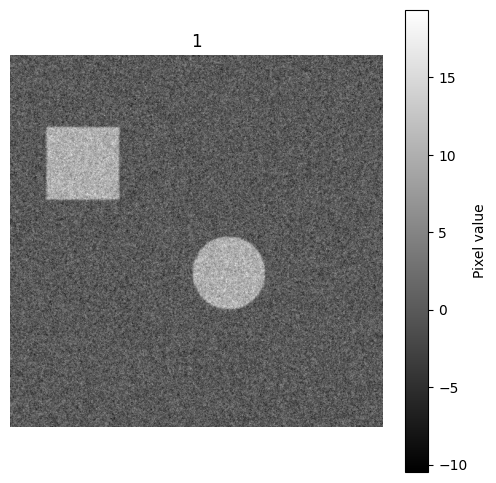

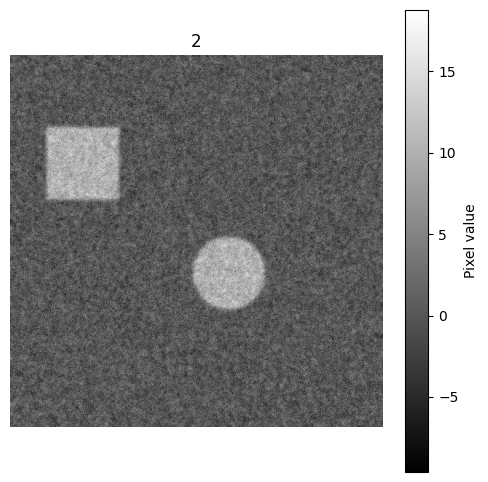

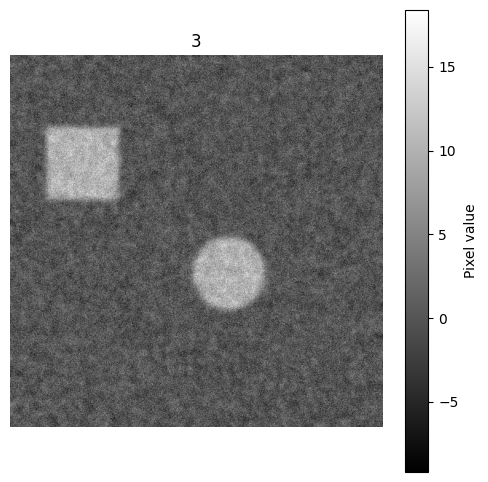

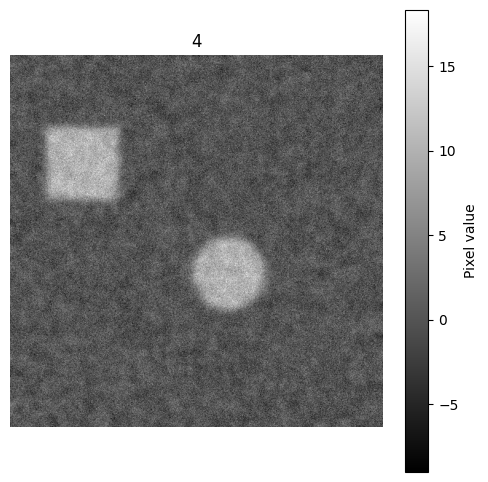

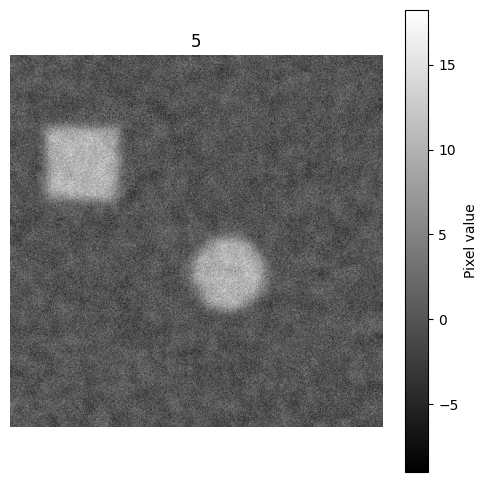

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

#aggiungiamo rumore con una distribuzione uniforme

rand_noise = np.random.normal(loc=0.0, scale=2, size=(512, 512))

clean_image = np.zeros((512, 512))
unitary_matrix = np.zeros((100, 100))
unitary_matrix[:] = 10

for i in range(100, 200):
    for j in range(50, 150):
        clean_image[i, j] += unitary_matrix[i-100, j-50]
        
        
cx, cy = 300, 300   # centro del cerchio (spostato a destra)
r = 50              # raggio
value = 10

for i in range(cx - r, cx + r):
    for j in range(cy - r, cy + r):
        if (i - cx)**2 + (j - cy)**2 <= r**2:
            clean_image[i, j] += value



plt.figure(figsize=(6, 6))
plt.imshow(clean_image, cmap='gray')
plt.colorbar(label='Pixel value')
plt.title("Clean Image (pixel view)")
plt.axis('off')
plt.show()

sigma = 0
for i in range(6):
    
    clean_image = gaussian_filter(clean_image, sigma=sigma)
    clean_image += rand_noise

    plt.figure(figsize=(6, 6))
    plt.imshow(clean_image, cmap='gray')
    plt.colorbar(label='Pixel value')
    plt.title(sigma)
    plt.axis('off')
    plt.show()
    sigma = sigma + 1

Can you invent a method to improve this behaviour?

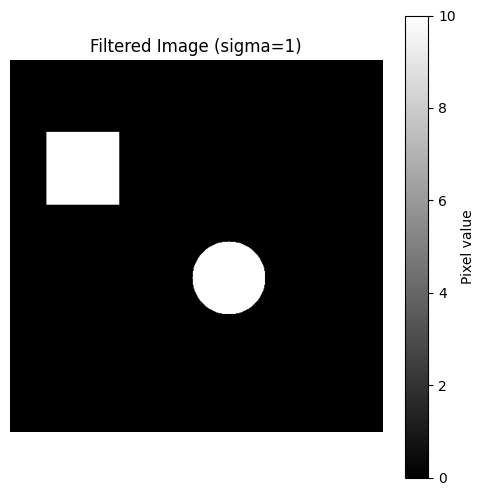

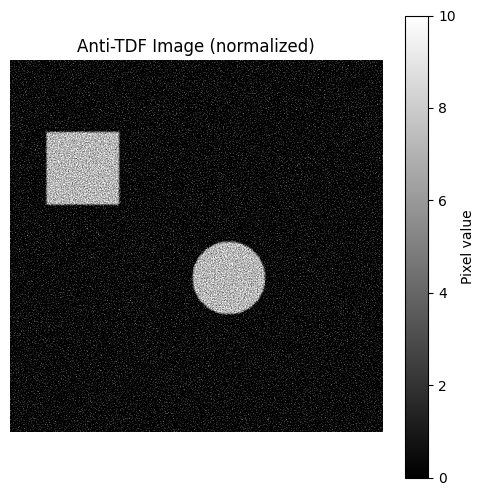

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

#aggiungiamo rumore con una distribuzione uniforme
sigma = 1.5
rand_noise = np.random.normal(loc=0.0, scale=1, size=(512, 512))

clean_image = np.zeros((512, 512))
unitary_matrix = np.zeros((100, 100))
unitary_matrix[:] = 10

for i in range(100, 200):
    for j in range(50, 150):
        clean_image[i, j] += unitary_matrix[i-100, j-50]
        
        
cx, cy = 300, 300   # centro del cerchio (spostato a destra)
r = 50              # raggio
value = 10

for i in range(cx - r, cx + r):
    for j in range(cy - r, cy + r):
        if (i - cx)**2 + (j - cy)**2 <= r**2:
            clean_image[i, j] += value



plt.figure(figsize=(6, 6))
plt.imshow(clean_image, cmap='gray')
plt.colorbar(label='Pixel value')
plt.title("Filtered Image (sigma=1)")
plt.axis('off')
plt.show()

def gaussian_kernel2d(shape,sigma):
    H, W = shape
    yy, xx = np.ogrid[:H, :W]
    
    cy,cx = H // 2, W // 2 #guassiana al centro del del quadrato
    g = np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sigma**2))
    
    g /= g.sum()
    
    return g

# Applicazione filtro Gaussiano
blurred_image = gaussian_filter(clean_image, sigma)
blurred_image += rand_noise
# FFT
tdf_image_b = fftn(blurred_image)


# Anti-convoluzione stabile con epsilon
epsilon = 0.4
tdf_gaussian = fftn(fftshift(gaussian_kernel2d(clean_image.shape, sigma))) #fftshift per ricentrare la gaussiana ed eliminare coefficienti di fase

tdf_image = tdf_image_b / (tdf_gaussian + epsilon) #per evitare artefatti o valori fuori scala
antitdf = np.real(ifftn(tdf_image))
antitdf_display = antitdf - antitdf.min()
antitdf_display = antitdf_display / antitdf_display.max() * 10

plt.figure(figsize=(6, 6))
plt.imshow(antitdf, cmap='gray', vmin=0, vmax=10)

plt.colorbar(label='Pixel value')
plt.title("Anti-TDF Image (normalized)")
plt.axis('off')
plt.show()


Suppose you don’t know the exact PSF. What happens if you deconvolve with a
gaussian with a (even slightly) wrong sigma?

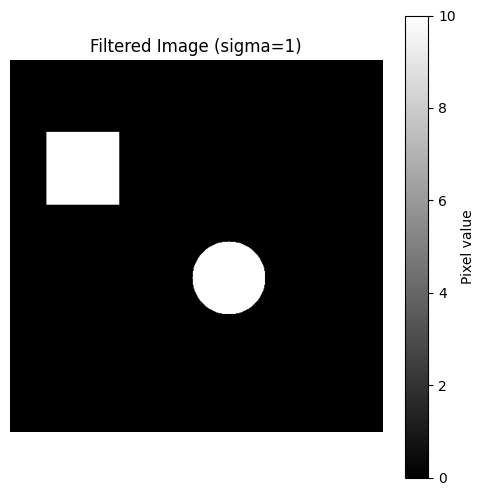

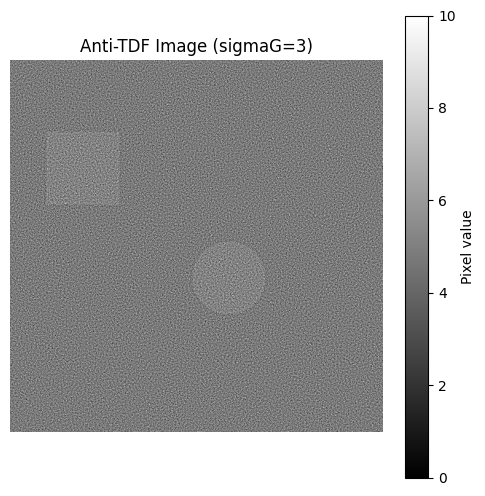

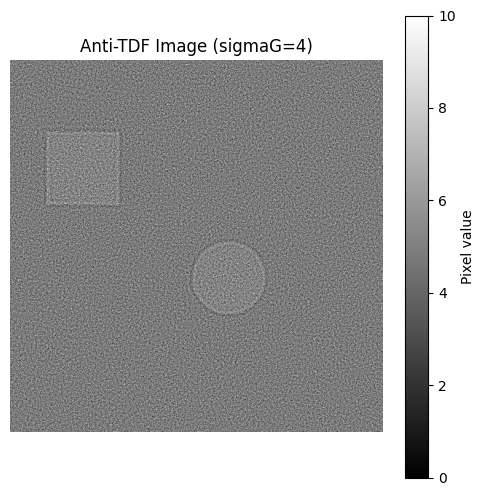

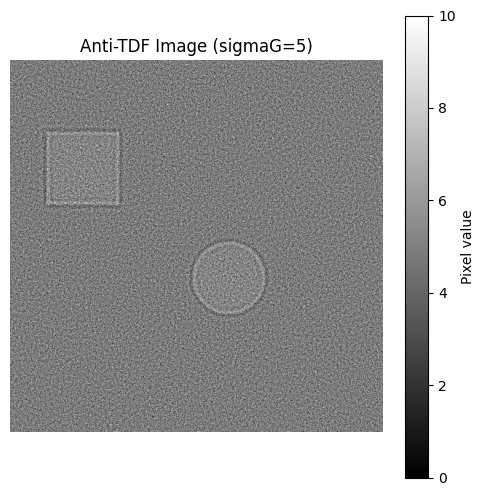

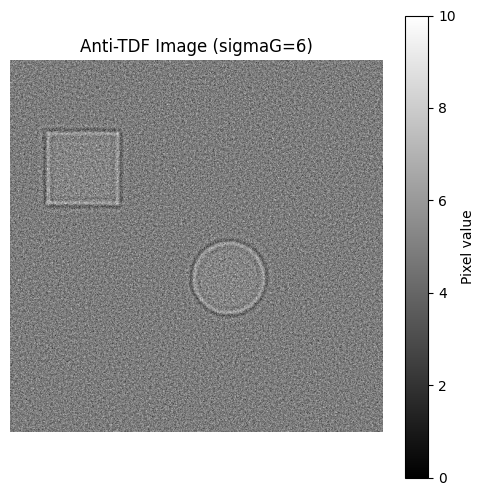

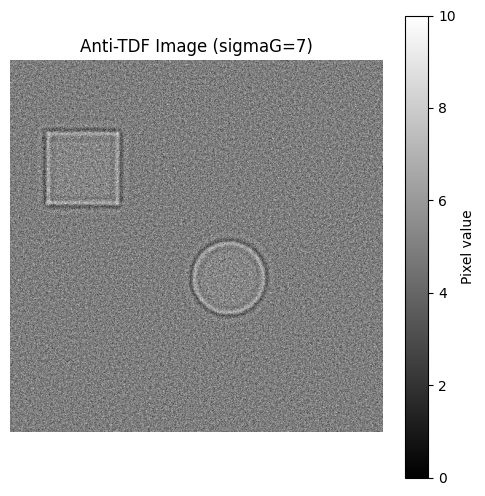

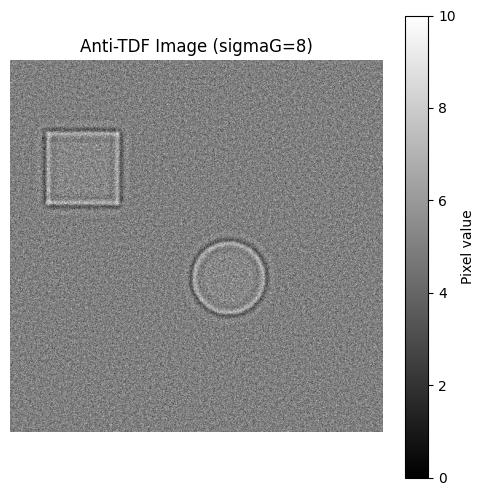

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

#aggiungiamo rumore con una distribuzione uniforme
sigma = 2
sigmaG=2

rand_noise = np.random.normal(loc=0.0, scale=1, size=(512, 512))

clean_image = np.zeros((512, 512))
unitary_matrix = np.zeros((100, 100))
unitary_matrix[:] = 10

for i in range(100, 200):
    for j in range(50, 150):
        clean_image[i, j] += unitary_matrix[i-100, j-50]
        
        
cx, cy = 300, 300   # centro del cerchio (spostato a destra)
r = 50              # raggio
value = 10

for i in range(cx - r, cx + r):
    for j in range(cy - r, cy + r):
        if (i - cx)**2 + (j - cy)**2 <= r**2:
            clean_image[i, j] += value



plt.figure(figsize=(6, 6))
plt.imshow(clean_image, cmap='gray')
plt.colorbar(label='Pixel value')
plt.title("Filtered Image (sigma=1)")
plt.axis('off')
plt.show()

def gaussian_kernel2d(shape,sigma):
    H, W = shape
    yy, xx = np.ogrid[:H, :W]
    
    cy,cx = H // 2, W // 2 #guassiana al centro del del quadrato
    g = np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sigma**2))
    
    g /= g.sum()
    
    return g

# Applicazione filtro Gaussiano
blurred_image = gaussian_filter(clean_image, sigma)
blurred_image += rand_noise
# FFT
tdf_image_b = fftn(blurred_image)


# Anti-convoluzione stabile con epsilon
epsilon = 0.03

for i in range(6):

    sigmaG = sigmaG + 1
    tdf_gaussian = fftn(fftshift(gaussian_kernel2d(clean_image.shape, sigmaG))) #fftshift per ricentrare la gaussiana ed eliminare coefficienti di fase

    tdf_image = tdf_image_b / (tdf_gaussian + epsilon) #per evitare artefatti o valori fuori scala
    antitdf = np.real(ifftn(tdf_image))
    antitdf_display = antitdf - antitdf.min()
    antitdf_display = antitdf_display / antitdf_display.max() * 10

    plt.figure(figsize=(6, 6))
    plt.imshow(antitdf_display, cmap='gray', vmin=0, vmax=10)

    plt.colorbar(label='Pixel value')
    plt.title(f"Anti-TDF Image (sigmaG={sigmaG})")
    plt.axis('off')
    plt.show()


The previous method was derived assuming no noise and that there exists an analytical
inverse of “A”. We can derive a much more general (but computationally slower) algorithm
without making any request about “A” and that minimizes the noise (in a maximum-likelihood
sense)

In [ ]:
#𝑔 = 𝐴𝑇[𝐴𝑥𝑖− 𝑦]
#𝑥𝑖+1 = 𝑥𝑖 + 𝛼𝑔

x = np.zeros((512,512))
N = 10
for i in range(N):
    

Starting optimization for up to 50 iterations...
Iter 00: Loss = 9.675e+05, alpha = 2.608e-04
Iter 01: Loss = 1.882e+05, alpha = 3.059e-04
Iter 02: Loss = 7.962e+04, alpha = 2.912e-04
Iter 03: Loss = 4.332e+04, alpha = 3.214e-04
Iter 04: Loss = 2.637e+04, alpha = 2.987e-04
Iter 05: Loss = 1.721e+04, alpha = 3.274e-04
Iter 06: Loss = 1.177e+04, alpha = 3.026e-04
Iter 07: Loss = 8.326e+03, alpha = 3.310e-04
Iter 08: Loss = 6.050e+03, alpha = 3.051e-04
Iter 09: Loss = 4.492e+03, alpha = 3.335e-04
Iter 10: Loss = 3.394e+03, alpha = 3.068e-04
Iter 11: Loss = 2.603e+03, alpha = 3.353e-04
Iter 12: Loss = 2.021e+03, alpha = 3.081e-04
Iter 13: Loss = 1.587e+03, alpha = 3.366e-04
Iter 14: Loss = 1.258e+03, alpha = 3.091e-04
Iter 15: Loss = 1.005e+03, alpha = 3.376e-04
Iter 16: Loss = 8.094e+02, alpha = 3.098e-04
Iter 17: Loss = 6.557e+02, alpha = 3.384e-04
Iter 18: Loss = 5.343e+02, alpha = 3.104e-04
Iter 19: Loss = 4.375e+02, alpha = 3.389e-04
Iter 20: Loss = 3.599e+02, alpha = 3.108e-04
Iter 2

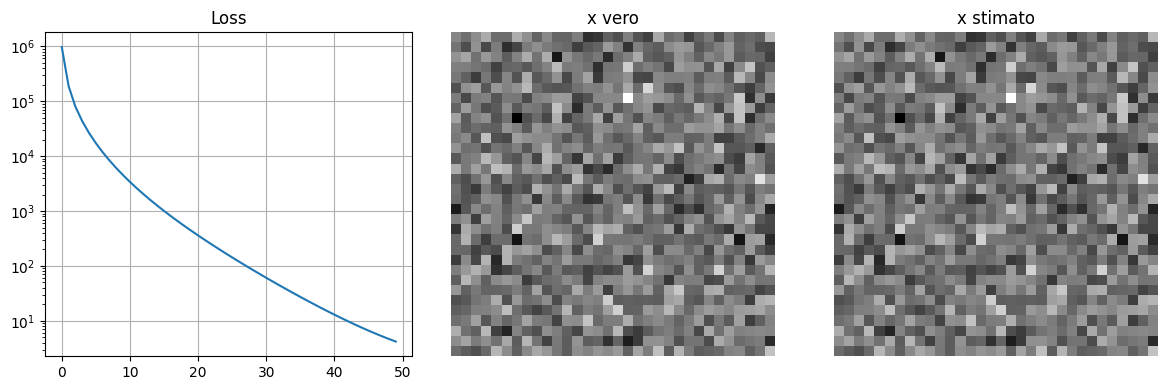

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def solve_iterative_reconstruction(A, y, max_iter=50, tol=1e-6):
    A = np.asarray(A)
    y = np.asarray(y).reshape(-1)
    M, N = A.shape

    x = np.zeros(N)
    losses = []

    print(f"Starting optimization for up to {max_iter} iterations...")

    for i in range(max_iter):
        residual = A @ x - y
        loss = 0.5 * np.linalg.norm(residual)**2
        losses.append(loss)

        g = A.T @ residual
        norm_g_sq = np.dot(g, g)

        if norm_g_sq < tol:
            print(f"Converged at iteration {i}")
            break

        Ag = A @ g
        norm_Ag_sq = np.dot(Ag, Ag)
        if norm_Ag_sq < 1e-12:
            break

        alpha = norm_g_sq / norm_Ag_sq
        x = x - alpha * g

        print(f"Iter {i:02d}: Loss = {loss:.3e}, alpha = {alpha:.3e}")

    return x, losses


# ------------------ EXAMPLE (CONSISTENTE) ------------------

np.random.seed(42)

H, W = 32, 32               # immagine piccola
N = H * W
M = 2 * N                  # problema sovradeterminato

x_true_vec = np.random.randn(N)
A = np.random.randn(M, N)

sigma = 0.05
y = A @ x_true_vec + sigma * np.random.randn(M)

x_estimated_vec, loss_history = solve_iterative_reconstruction(A, y)

x_true_img = x_true_vec.reshape(H, W)
x_estimated_img = x_estimated_vec.reshape(H, W)

# ------------------ PLOT ------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(loss_history)
plt.yscale("log")
plt.title("Loss")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.imshow(x_true_img, cmap="gray")
plt.title("x vero")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(x_estimated_img, cmap="gray")
plt.title("x stimato")
plt.axis("off")

plt.tight_layout()
plt.show()
